In [3]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

# items 데이터셋

In [6]:
df_items = pd.read_csv("C반과제-유통-새벽배송매출증대/on_items.csv", encoding="cp949")
df_items.head()

,ItemLargeCode,ItemLargeName,ItemMiddleCode,ItemMiddleName,ItemSmallCode,ItemSmallName,ItemCode,ItemName,PriceYear,PriceMin,PriceMax
0,L1,가공식품,M11,곡물,S0080,국수,L1-M11-S0080-1001,(식품)샘표 김치국수 101g 10입,2023,15840,16130
1,L1,가공식품,M11,곡물,S0080,국수,L1-M11-S0080-1001,(식품)샘표 김치국수 101g 10입,2024,17030,17340
2,L1,가공식품,M11,곡물,S0080,국수,L1-M11-S0080-1001,(식품)샘표 김치국수 101g 10입,2025,17380,18640
3,L1,가공식품,M11,곡물,S0080,국수,L1-M11-S0080-1002,2.1kg 6배 메밀 Bestco 희석용 소바 국수장국,2024,14160,15350
4,L1,가공식품,M11,곡물,S0080,국수,L1-M11-S0080-1002,2.1kg 6배 메밀 Bestco 희석용 소바 국수장국,2025,15060,16160


In [7]:
df_items.shape

(10054, 11)

In [102]:
df_items.isnull().sum()

ItemLargeCode     0
ItemLargeName     0
ItemMiddleCode    0
ItemMiddleName    0
ItemSmallCode     0
ItemSmallName     0
ItemCode          0
ItemName          0
PriceYear         0
PriceMin          0
PriceMax          0
dtype: int64

In [103]:
print("=== df_items 고유값 개수 ===")
print(df_items.nunique())

=== df_items 고유값 개수 ===
ItemLargeCode        4
ItemLargeName        4
ItemMiddleCode      14
ItemMiddleName      14
ItemSmallCode       58
ItemSmallName       59
ItemCode          3990
ItemName          3989
PriceYear            3
PriceMin          2917
PriceMax          3070
dtype: int64


In [123]:
# === 카테고리 코드-이름 매핑 확인 ===

print("=== Large 카테고리 ===")
for _, row in df_items[['ItemLargeCode', 'ItemLargeName']].drop_duplicates().sort_values('ItemLargeCode').iterrows():
    print(f"{row['ItemLargeCode']}  {row['ItemLargeName']}")

print("\n=== Middle 카테고리 ===")
for _, row in df_items[['ItemMiddleCode', 'ItemMiddleName']].drop_duplicates().sort_values('ItemMiddleCode').iterrows():
    print(f"{row['ItemMiddleCode']}  {row['ItemMiddleName']}")

print("\n=== Small 카테고리 ===")
for _, row in df_items[['ItemSmallCode', 'ItemSmallName']].drop_duplicates().sort_values('ItemSmallCode').iterrows():
    print(f"{row['ItemSmallCode']}  {row['ItemSmallName']}")

=== Large 카테고리 ===
L1  가공식품
L3  생수
L4  신선식품
L5  음료

=== Middle 카테고리 ===
M11  곡물
M12  과일
M13  과자
M15  냉동
M16  생수
M17  수산
M18  신선
M19  양념
M20  음료
M21  즉석
M22  채소
M23  축산
M24  커피
M25  탄산

=== Small 카테고리 ===
S0020  고구마
S0030  고등어
S0040  나물
S0070  과일
S0080  국수
S0100  김
S0110  김치
S0130  낙지
S0140  냉동
S0160  당면
S0170  도라지
S0190  드레싱
S0200  딸기
S0210  땅콩
S0220  라면
S0230  멸치
S0240  마른
S0240  오징어
S0250  맛김
S0260  미역
S0280  밤
S0290  배
S0310  북어
S0330  블루베리
S0340  빵
S0350  사과
S0360  상추
S0380  생선
S0390  생수
S0420  소시지
S0430  수박
S0440  스낵
S0480  아몬드
S0500  오징어
S0520  잼
S0530  전복
S0540  즉석
S0540  전복
S0560  참외
S0580  치즈
S0590  카레
S0600  커피
S0620  키위
S0630  탄산음료
S0640  토마토
S0650  파
S0660  파스타
S0670  파프리카
S0680  풋고추
S0700  호박
S0720  혼합음료
S0720  이온음료
S0730  조미료
S0800  갈치
S0810  조기
S0850  깻잎
S0860  콩나물
S0900  계란
S0910  닭고기
S0920  돼지고기
S0930  쇠고기


In [124]:
# === ItemName 카테고리 계층 매핑 확인 ===
cols = ['ItemLargeCode', 'ItemLargeName', 'ItemMiddleCode', 'ItemMiddleName', 'ItemSmallCode', 'ItemSmallName', 'ItemName']
df_check = df_items[cols].sort_values(['ItemLargeCode', 'ItemMiddleCode', 'ItemSmallCode', 'ItemName'])

for _, row in df_check.iterrows():
    print(f"{row['ItemLargeCode']} {row['ItemLargeName']}  {row['ItemMiddleCode']} {row['ItemMiddleName']}  {row['ItemSmallCode']} {row['ItemSmallName']}  {row['ItemName']}")

L1 가공식품  M11 곡물  S0080 국수  (식품)샘표 김치국수 101g 10입
L1 가공식품  M11 곡물  S0080 국수  (식품)샘표 김치국수 101g 10입
L1 가공식품  M11 곡물  S0080 국수  (식품)샘표 김치국수 101g 10입
L1 가공식품  M11 곡물  S0080 국수  2.1kg 6배 메밀 Bestco 희석용 소바 국수장국
L1 가공식품  M11 곡물  S0080 국수  2.1kg 6배 메밀 Bestco 희석용 소바 국수장국
L1 가공식품  M11 곡물  S0080 국수  500G 오뚜기 옛날 국수소면 x 12개
L1 가공식품  M11 곡물  S0080 국수  500G 오뚜기 옛날 국수소면 x 12개
L1 가공식품  M11 곡물  S0080 국수  500G 오뚜기 옛날 국수소면 x 12개
L1 가공식품  M11 곡물  S0080 국수  CJ 제일제면소중면 900G 국수  단일 수량
L1 가공식품  M11 곡물  S0080 국수  CJ 제일제면소중면 900G 국수  단일 수량
L1 가공식품  M11 곡물  S0080 국수  CJ 제일제면소중면 900G 국수  단일 수량
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소 소면 900g 국수 소면 소바 칼국수 스파게티
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소 소면 900g 국수 소면 소바 칼국수 스파게티
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소 소면 900g 국수 소면 소바 칼국수 스파게티
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소(소면)900g 국수 소면 소바 칼국수 스파게티
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소(소면)900g 국수 소면 소바 칼국수 스파게티
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소(소면)900g 국수 소면 소바 칼국수 스파게티
L1 가공식품  M11 곡물  S0080 국수  CJ백설 제일제면소칼국수900g 국수

In [105]:
df_items.describe()

,PriceYear,PriceMin,PriceMax
count,10054.000000,10054.000000,10054.000000
mean,2024.122439,14484.521583,15552.627810
std,0.810645,9332.507901,10015.526676
min,2023.000000,960.000000,1020.000000
25%,2023.000000,6660.000000,7140.000000
50%,2024.000000,12840.000000,13810.000000
75%,2025.000000,21117.500000,22670.000000
max,2025.000000,38590.000000,41390.000000


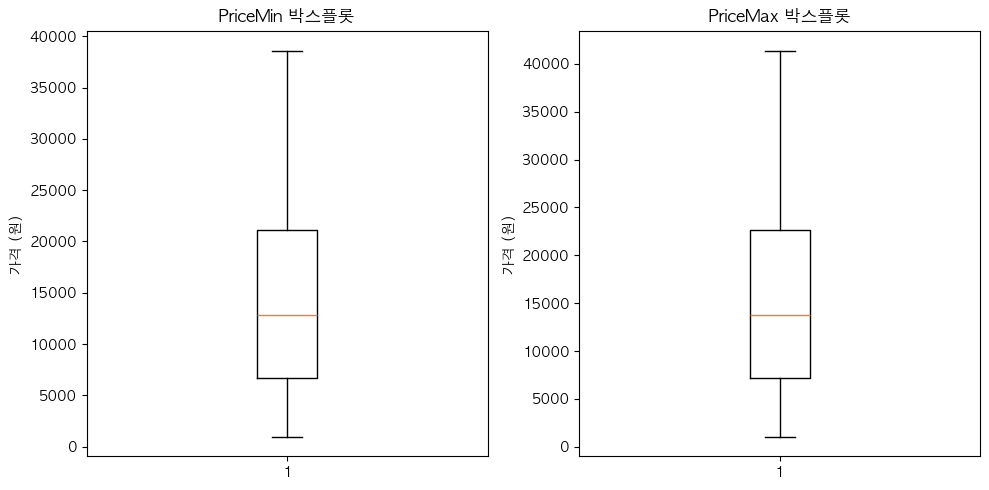

PriceMin 이상치 수: 0, 범위: [-15026, 42804]
PriceMax 이상치 수: 0, 범위: [-16155, 45965]


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(df_items['PriceMin'].dropna())
axes[0].set_title('PriceMin 박스플롯')
axes[0].set_ylabel('가격 (원)')

axes[1].boxplot(df_items['PriceMax'].dropna())
axes[1].set_title('PriceMax 박스플롯')
axes[1].set_ylabel('가격 (원)')

plt.tight_layout()
plt.show()

# 이상치 기준: IQR 방법
for col in ['PriceMin', 'PriceMax']:
    Q1 = df_items[col].quantile(0.25)
    Q3 = df_items[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_items[(df_items[col] < Q1 - 1.5 * IQR) | (df_items[col] > Q3 + 1.5 * IQR)]
    print(f"{col} 이상치 수: {len(outliers)}, 범위: [{Q1 - 1.5*IQR:.0f}, {Q3 + 1.5*IQR:.0f}]")

In [138]:
# Large 매칭 확인                                                                                                                                                                 
print("=== Large 매칭 확인 ===")                                                                                                                                                  
large_check = df_items.groupby('ItemCode')[['ItemLargeCode', 'ItemLargeName']].nunique()                                                                                          
mismatch_large = (large_check.max(axis=1) > 1).sum()                                                                                                                              
print(f"ItemCode당 ItemLargeCode 개수: {large_check['ItemLargeCode'].max()}개 이하")                                                                                              
print(f"매칭 불일치 건수: {mismatch_large}건")                                                                                                                                    
if mismatch_large > 0:                                                                                                                                                            
    print(f"불일치 사례: {large_check[large_check.max(axis=1) > 1].head()}")                                                                                                      
                                                                                                                                                                                
# Middle 매칭 확인                                                           
print("\n=== Middle 매칭 확인 ===")                                                                                                                                               
middle_check = df_items.groupby('ItemCode')[['ItemMiddleCode', 'ItemMiddleName']].nunique()
mismatch_middle = (middle_check.max(axis=1) > 1).sum()                                                                                                                            
print(f"ItemCode당 ItemMiddleCode 개수: {middle_check['ItemMiddleCode'].max()}개 이하")                                                                                           
print(f"매칭 불일치 건수: {mismatch_middle}건")                                                                                                                                   
if mismatch_middle > 0:                                                                                                                                                           
    print(f"불일치 사례: {middle_check[middle_check.max(axis=1) > 1].head()}")                                                                                                    
                                                                                                                                                                                
# Small 매칭 확인                                                                                                                                                                 
print("\n=== Small 매칭 확인 ===")                                                                                                                                                
small_check = df_items.groupby('ItemCode')[['ItemSmallCode', 'ItemSmallName']].nunique()                                                                                          
mismatch_small = (small_check.max(axis=1) > 1).sum()                                                                                                                              
print(f"ItemCode당 ItemSmallCode 개수: {small_check['ItemSmallCode'].max()}개 이하")                                                                                              
print(f"매칭 불일치 건수: {mismatch_small}건")                                                                                                                                    
if mismatch_small > 0:                                                                                                                                                            
    print(f"불일치 사례: {small_check[small_check.max(axis=1) > 1].head()}")                                                                                                      
                                                                                                                                                                                
                                                                                                            


=== Large 매칭 확인 ===
ItemCode당 ItemLargeCode 개수: 1개 이하
매칭 불일치 건수: 0건

=== Middle 매칭 확인 ===
ItemCode당 ItemMiddleCode 개수: 1개 이하
매칭 불일치 건수: 0건

=== Small 매칭 확인 ===
ItemCode당 ItemSmallCode 개수: 1개 이하
매칭 불일치 건수: 0건


In [140]:
# === SmallCode가 같은데 SmallName이 다른 경우 ===
small_map = df_items.groupby('ItemSmallCode')['ItemSmallName'].nunique()
dup_codes = small_map[small_map > 1].index

result = (df_items[df_items['ItemSmallCode'].isin(dup_codes)]
          [['ItemSmallCode', 'ItemSmallName']]
          .drop_duplicates()
          .sort_values(['ItemSmallCode', 'ItemSmallName']))
print(f"해당 SmallCode 수: {len(dup_codes)}건")
print(result.to_string(index=False))

해당 SmallCode 수: 3건
ItemSmallCode ItemSmallName
        S0240            마른
        S0240           오징어
        S0540            전복
        S0540            즉석
        S0720          이온음료
        S0720          혼합음료


In [139]:
# === SmallName이 같은데 SmallCode가 다른 경우 ===
name_map = df_items.groupby('ItemSmallName')['ItemSmallCode'].nunique()
dup_names = name_map[name_map > 1].index

result = (df_items[df_items['ItemSmallName'].isin(dup_names)]
          [['ItemSmallCode', 'ItemSmallName']]
          .drop_duplicates()
          .sort_values(['ItemSmallName', 'ItemSmallCode']))
print(f"해당 SmallName 수: {len(dup_names)}건")
print(result.to_string(index=False))

해당 SmallName 수: 2건
ItemSmallCode ItemSmallName
        S0240           오징어
        S0500           오징어
        S0530            전복
        S0540            전복


# orders 데이터셋

In [93]:
df_orders = pd.read_csv("C반과제-유통-새벽배송매출증대/on_orders.csv", encoding="cp949")
df_orders.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT
0,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M17-S0530-1024,33310,07JAN2023:06:24:00
1,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M21-S0540-1082,3780,07JAN2023:06:24:00
2,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M15-S0140-1311,22520,07JAN2023:06:24:00
3,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M12-S0350-1035,21630,07JAN2023:06:24:00
4,U10001,U10001-O2023-1003,13JAN2023:16:50:14,L4-M12-S0640-1057,11700,14JAN2023:06:28:00


In [94]:
df_orders.shape

(855365, 6)

In [95]:
df_orders.isnull().sum()

idUser        0
idOrder       0
OrderDT       0
ItemCode      0
Price         0
DeliveryDT    0
dtype: int64

In [96]:
print("\n=== df_orders 고유값 개수 ===")
print(df_orders.nunique())


=== df_orders 고유값 개수 ===
idUser          3000
idOrder       171431
OrderDT       171351
ItemCode        3989
Price           3986
DeliveryDT    106844
dtype: int64


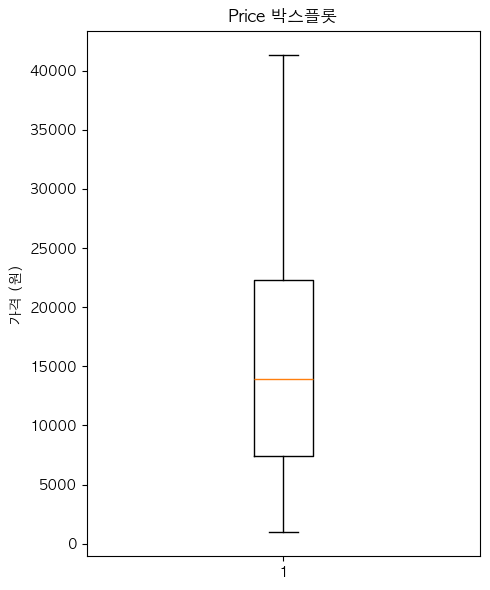

Price 이상치 수: 0, 범위: [-14955, 44685]


In [110]:
fig, ax = plt.subplots(figsize=(5, 6))

ax.boxplot(df_orders['Price'].dropna())
ax.set_title('Price 박스플롯')
ax.set_ylabel('가격 (원)')

plt.tight_layout()
plt.show()

# 이상치 기준: IQR 방법
Q1 = df_orders['Price'].quantile(0.25)
Q3 = df_orders['Price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_orders[(df_orders['Price'] < Q1 - 1.5 * IQR) | (df_orders['Price'] > Q3 + 1.5 * IQR)]
print(f"Price 이상치 수: {len(outliers)}, 범위: [{Q1 - 1.5*IQR:.0f}, {Q3 + 1.5*IQR:.0f}]")

In [97]:
# OrderDT, DeliveryDT datetime 파싱 (errors='coerce'로 잘못된 날짜 NaT 처리)
df_orders['OrderDT'] = pd.to_datetime(df_orders['OrderDT'], format='%d%b%Y:%H:%M:%S', errors='coerce')
df_orders['DeliveryDT'] = pd.to_datetime(df_orders['DeliveryDT'], format='%d%b%Y:%H:%M:%S', errors='coerce')

# 파싱 실패(NaT) 행 확인 및 제거
nat_mask = df_orders['OrderDT'].isna() | df_orders['DeliveryDT'].isna()
print(f"파싱 실패(NaT) 행 수: {nat_mask.sum()}")
df_orders = df_orders[~nat_mask].reset_index(drop=True)

# 2024년 2월 29일 제거 (OrderDT 또는 DeliveryDT가 해당 날짜인 행)
mask_feb29 = (
    ((df_orders['OrderDT'].dt.year == 2024) & (df_orders['OrderDT'].dt.month == 2) & (df_orders['OrderDT'].dt.day == 29)) |
    ((df_orders['DeliveryDT'].dt.year == 2024) & (df_orders['DeliveryDT'].dt.month == 2) & (df_orders['DeliveryDT'].dt.day == 29))
)
df_orders = df_orders[~mask_feb29].reset_index(drop=True)
print(f"2024-02-29 제거된 행 수: {mask_feb29.sum()}, 남은 행 수: {len(df_orders)}")

# OrderDT 분리
df_orders['Order_Year']   = df_orders['OrderDT'].dt.year
df_orders['Order_Month']  = df_orders['OrderDT'].dt.month
df_orders['Order_Day']    = df_orders['OrderDT'].dt.day
df_orders['Order_Hour']   = df_orders['OrderDT'].dt.hour
df_orders['Order_Minute'] = df_orders['OrderDT'].dt.minute
df_orders['Order_Second'] = df_orders['OrderDT'].dt.second

# DeliveryDT 분리
df_orders['Delivery_Year']   = df_orders['DeliveryDT'].dt.year
df_orders['Delivery_Month']  = df_orders['DeliveryDT'].dt.month
df_orders['Delivery_Day']    = df_orders['DeliveryDT'].dt.day
df_orders['Delivery_Hour']   = df_orders['DeliveryDT'].dt.hour
df_orders['Delivery_Minute'] = df_orders['DeliveryDT'].dt.minute
df_orders['Delivery_Second'] = df_orders['DeliveryDT'].dt.second

df_orders.head()

파싱 실패(NaT) 행 수: 2326
2024-02-29 제거된 행 수: 0, 남은 행 수: 853039


,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,Order_Year,Order_Month,Order_Day,Order_Hour,Order_Minute,Order_Second,Delivery_Year,Delivery_Month,Delivery_Day,Delivery_Hour,Delivery_Minute,Delivery_Second
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,8,51,2023,1,7,6,24,0
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,8,51,2023,1,7,6,24,0
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,8,51,2023,1,7,6,24,0
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,8,51,2023,1,7,6,24,0
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,50,14,2023,1,14,6,28,0


In [99]:
# 배달 마감시간: 21시 이전 주문 → 다음날 07:00, 21시 이후 주문 → 이틀 후 07:00
df_orders['DeliveryDeadline'] = df_orders['OrderDT'].apply(
    lambda x: x.normalize() + pd.Timedelta(days=1, hours=7)
    if x.hour < 21
    else x.normalize() + pd.Timedelta(days=2, hours=7)
)

# 배달 지연 여부 (DeliveryDT가 마감시간 초과면 지연)
df_orders['IsLate'] = df_orders['DeliveryDT'] > df_orders['DeliveryDeadline']

# 지연 건수 및 비율
late_count = df_orders['IsLate'].sum()
print(f"배달 지연 건수: {late_count:,}")
print(f"전체 대비 비율: {late_count / len(df_orders) * 100:.2f}%")

# 지연된 행 확인
df_late = df_orders[df_orders['IsLate']][['idUser', 'idOrder', 'OrderDT', 'DeliveryDT', 'DeliveryDeadline']]
print(f"\n지연된 행 목록 (상위 10건):")
df_late.head(10)

배달 지연 건수: 55,127
전체 대비 비율: 6.46%

지연된 행 목록 (상위 10건):


,idUser,idOrder,OrderDT,DeliveryDT,DeliveryDeadline
48,U10001,U10001-O2023-1010,2023-03-31 19:58:32,2023-04-01 07:23:00,2023-04-01 07:00:00
49,U10001,U10001-O2023-1010,2023-03-31 19:58:32,2023-04-01 07:23:00,2023-04-01 07:00:00
50,U10001,U10001-O2023-1010,2023-03-31 19:58:32,2023-04-01 07:23:00,2023-04-01 07:00:00
51,U10001,U10001-O2023-1010,2023-03-31 19:58:32,2023-04-01 07:23:00,2023-04-01 07:00:00
52,U10001,U10001-O2023-1010,2023-03-31 19:58:32,2023-04-01 07:23:00,2023-04-01 07:00:00
53,U10001,U10001-O2023-1011,2023-05-05 10:52:19,2023-05-06 07:58:00,2023-05-06 07:00:00
54,U10001,U10001-O2023-1011,2023-05-05 10:52:19,2023-05-06 07:58:00,2023-05-06 07:00:00
91,U10001,U10001-O2023-1021,2023-09-10 08:18:12,2023-09-12 05:56:00,2023-09-11 07:00:00
92,U10001,U10001-O2023-1021,2023-09-10 08:18:12,2023-09-12 05:56:00,2023-09-11 07:00:00
93,U10001,U10001-O2023-1021,2023-09-10 08:18:12,2023-09-12 05:56:00,2023-09-11 07:00:00


# users 데이터셋

In [129]:
df_users = pd.read_csv("C반과제-유통-새벽배송매출증대/on_users.csv", encoding="cp949")
df_users.head()

,idUser,Gender,Age,FamilyCount,MemberYN
0,U10001,여성,26,2,Y
1,U10002,남성,61,2,Y
2,U10003,여성,34,2,Y
3,U10004,남성,26,1,N
4,U10005,여성,33,3,Y


In [130]:
df_users.shape

(3000, 5)

In [131]:
df_users.describe()

,Age,FamilyCount
count,3000.000000,3000.000000
mean,36.785667,1.622667
std,10.949141,0.971563
min,21.000000,0.000000
25%,29.000000,1.000000
50%,35.000000,2.000000
75%,43.000000,2.000000
max,69.000000,3.000000


In [132]:
df_users.isnull().sum()

idUser         0
Gender         0
Age            0
FamilyCount    0
MemberYN       0
dtype: int64

In [ ]:
print("\n=== df_users 고유값 개수 ===")
print(df_users.nunique())


=== df_orders 고유값 개수 ===
idUser         3000
Gender            2
Age              49
FamilyCount       4
MemberYN          2
dtype: int64


In [134]:
count = (df_users['Age'] < 20).sum()                                                                                                                                              
print(f"20살 미만 고객 수: {count}") 

20살 미만 고객 수: 0


In [135]:
count60 = (df_users['Age'] > 60).sum()                                                                                                                                              
print(f"60살 이상 고객 수: {count60}") 

60살 이상 고객 수: 114


In [136]:
df_users['AgeGroup'] = pd.cut(df_users['Age'], bins=[19, 29, 39, 49, 59, 69], labels=[20, 30, 40 , 50 ,60])
print(df_users[['Age', 'AgeGroup']].head(10))
print(f"\nAgeGroup 분포:\n{df_users['AgeGroup'].value_counts().sort_index()}")

   Age AgeGroup
0   26       20
1   61       60
2   34       30
3   26       20
4   33       30
5   37       30
6   29       20
7   24       20
8   21       20
9   44       40

AgeGroup 분포:
AgeGroup
20     820
30    1280
40     477
50     291
60     132
Name: count, dtype: int64


In [137]:
df_users.head()

,idUser,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,여성,26,2,Y,20
1,U10002,남성,61,2,Y,60
2,U10003,여성,34,2,Y,30
3,U10004,남성,26,1,N,20
4,U10005,여성,33,3,Y,30


In [141]:
df_users.to_csv('df_users.csv', index=False, encoding='cp949')

# 최종데이터셋

In [143]:
df_users = pd.read_csv("df_users.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,PriceYear,Gender,Age,FamilyCount,MemberYN,ItemLargeCode,ItemLargeName,ItemMiddleCode,ItemMiddleName,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax
0,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M17-S0530-1024,33310,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L4,신선식품,M17,수산,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0
1,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M21-S0540-1082,3780,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L1,가공식품,M21,즉석,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0
2,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M15-S0140-1311,22520,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L1,가공식품,M15,냉동,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0
3,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M12-S0350-1035,21630,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L4,신선식품,M12,과일,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0
4,U10001,U10001-O2023-1003,13JAN2023:16:50:14,L4-M12-S0640-1057,11700,14JAN2023:06:28:00,2023.0,여성,26,2,Y,L4,신선식품,M12,과일,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0


In [145]:
df_items = pd.read_csv("clean_item.csv")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,PriceYear,Gender,Age,FamilyCount,MemberYN,ItemLargeCode,ItemLargeName,ItemMiddleCode,ItemMiddleName,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax
0,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M17-S0530-1024,33310,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L4,신선식품,M17,수산,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0
1,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M21-S0540-1082,3780,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L1,가공식품,M21,즉석,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0
2,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M15-S0140-1311,22520,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L1,가공식품,M15,냉동,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0
3,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M12-S0350-1035,21630,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L4,신선식품,M12,과일,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0
4,U10001,U10001-O2023-1003,13JAN2023:16:50:14,L4-M12-S0640-1057,11700,14JAN2023:06:28:00,2023.0,여성,26,2,Y,L4,신선식품,M12,과일,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0


In [146]:
df_orders = pd.read_csv("orders.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,PriceYear,Gender,Age,FamilyCount,MemberYN,ItemLargeCode,ItemLargeName,ItemMiddleCode,ItemMiddleName,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax
0,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M17-S0530-1024,33310,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L4,신선식품,M17,수산,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0
1,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M21-S0540-1082,3780,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L1,가공식품,M21,즉석,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0
2,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L1-M15-S0140-1311,22520,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L1,가공식품,M15,냉동,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0
3,U10001,U10001-O2023-1002,06JAN2023:17:08:51,L4-M12-S0350-1035,21630,07JAN2023:06:24:00,2023.0,여성,26,2,Y,L4,신선식품,M12,과일,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0
4,U10001,U10001-O2023-1003,13JAN2023:16:50:14,L4-M12-S0640-1057,11700,14JAN2023:06:28:00,2023.0,여성,26,2,Y,L4,신선식품,M12,과일,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0
